In [1]:
import pandas as pd

df = pd.read_csv('Car Data.csv')

print(df.shape)
df.info()
df.head()

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# This dataset is from around 2020, so we'll use that as our reference point
df['Car_Age'] = 2020 - df['Year']

# Drop columns we won't use:
# - Car_Name has too many unique values to be useful without heavy extra work
# - Year is now redundant since we have Car_Age
df = df.drop(['Car_Name', 'Year'], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [3]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# X = everything except the target, y = the price we want to predict
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

# Split into training and testing sets, same idea as before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression - the standard first model for predicting a NUMBER (not a category)
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# R² score: how well does the model explain the variation in price? (1.0 = perfect, 0 = useless)
r2 = r2_score(y_test, predictions)

# Mean Absolute Error: on average, how far off are our price predictions? (in lakhs)
mae = mean_absolute_error(y_test, predictions)

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.3f} lakhs")

R² Score: 0.849
Mean Absolute Error: 1.216 lakhs


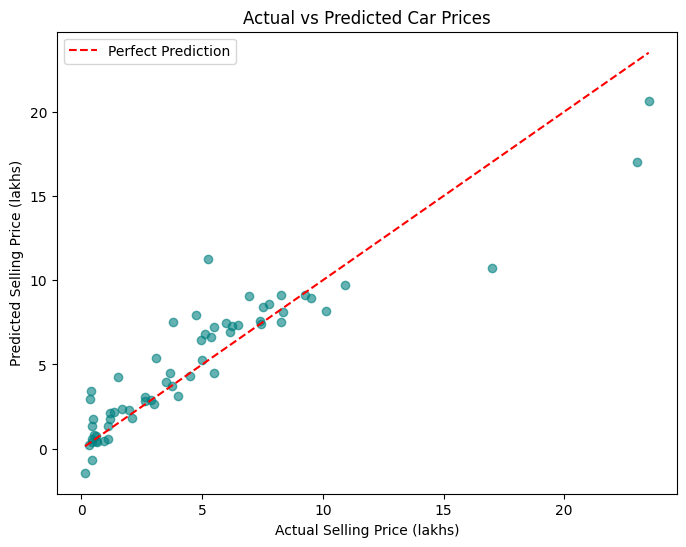

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Selling Price (lakhs)')
plt.ylabel('Predicted Selling Price (lakhs)')
plt.title('Actual vs Predicted Car Prices')
plt.legend()
plt.show()

In [6]:
import pandas as pd

feature_importance = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(feature_importance)

Fuel_Type_Diesel           2.534904
Transmission_Manual       -1.640074
Selling_type_Individual   -1.191642
Owner                     -0.905018
Fuel_Type_Petrol           0.739155
Present_Price              0.429070
Car_Age                   -0.352925
Driven_kms                -0.000006
dtype: float64
